First, lets start with the MLP code fully simplified:

In [19]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
len(words)

32033

In [5]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [7]:
# create splits
block_size = 3
def build_dataset(words):
    X, Y = [], []    
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])      # 80%
Xdev, Ydev = build_dataset(words[n1:n2])  # 10%
Xte, Yte = build_dataset(words[n2:])      # 10%

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [15]:
# MLP
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),                generator = g)
W1 = torch.randn((n_embd * block_size, n_hidden),    generator = g)
b1 = torch.randn((n_hidden),                         generator = g)
W2 = torch.randn((n_hidden, vocab_size),             generator = g)
b2 = torch.randn((vocab_size),                       generator = g)
parameters = [C, W1, b1, W2, b2]

print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

11897


In [16]:
# Optimization
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # gradient descent
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 26.5404
  10000/ 200000: 2.7627
  20000/ 200000: 2.5425
  30000/ 200000: 2.2364
  40000/ 200000: 2.4016
  50000/ 200000: 2.6819
  60000/ 200000: 2.3392
  70000/ 200000: 2.3078
  80000/ 200000: 2.1465
  90000/ 200000: 2.0149
 100000/ 200000: 2.3975
 110000/ 200000: 2.3679
 120000/ 200000: 2.2823
 130000/ 200000: 2.3762
 140000/ 200000: 2.2476
 150000/ 200000: 2.3361
 160000/ 200000: 2.1113
 170000/ 200000: 2.1349
 180000/ 200000: 2.3833
 190000/ 200000: 2.0264


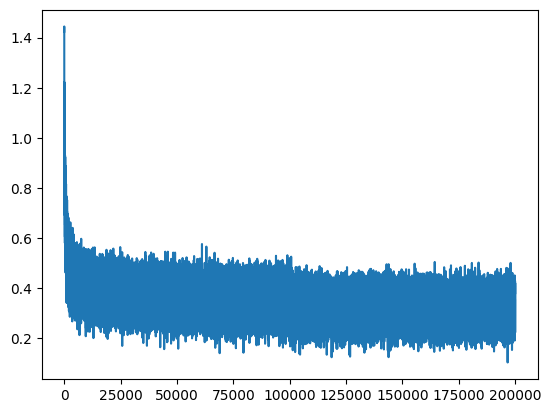

In [17]:
plt.plot(lossi)

In [18]:
# Evaluate
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.11914324760437
val 2.162384510040283


In [20]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)
for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        # forward pass the neural net
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)

        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out)) # decode and print the generated word

carmah.
ambrilli.
kimri.
rehtlinna.
sane.
mahnen.
deliah.
jaree.
corrisephanaiir.
kaleigh.
ham.
join.
quinton.
lilea.
jamilio.
jerry.
jarynix.
kael.
drudi.
emmedo.


This is fine, but something to note. The starting loss is lmost 26, then steeply drops by a lot, in the first step. While this is expected, this specific case is very extreme. The reason for that is that at initialization, the weights and biases w2 and b2 are randomized, causing the probability distribution to be skewed at the start. This causes the logits to be very widely variant, and the softmax to skew the probabilties in the distribution. It suddenly drops because after the first step, w2 and b2 are quickly modified. To fix it, at initialization, we can initialize b2 to all 0s to start, and scale down w2. Its not good practice to initialize weights to 0.

For a smoother training process, we can set b2 to zeroes at initialization and scale down the random predictions by 100x.

In [21]:
logits[0]

tensor([ 7.9770,  4.3978,  3.4003,  5.2660,  5.0737,  4.1919, -0.3467,  1.6445,
         2.1685,  1.2474,  3.2036,  3.6468,  6.0380,  5.8891,  8.6782,  5.8258,
         1.2348, -4.4538,  7.8290,  5.5572,  4.6882,  5.1242,  2.2532,  1.8191,
         6.4225,  4.2088,  5.7476], grad_fn=<SelectBackward0>)

11897
      0/ 200000: 3.3148
  10000/ 200000: 2.5742
  20000/ 200000: 2.6898
  30000/ 200000: 2.2988
  40000/ 200000: 2.1017
  50000/ 200000: 2.3964
  60000/ 200000: 2.7042
  70000/ 200000: 2.3947
  80000/ 200000: 2.2873
  90000/ 200000: 2.2870
 100000/ 200000: 2.1481
 110000/ 200000: 2.1402
 120000/ 200000: 2.0515
 130000/ 200000: 2.2054
 140000/ 200000: 2.3040
 150000/ 200000: 2.0718
 160000/ 200000: 2.0103
 170000/ 200000: 1.8712
 180000/ 200000: 2.3130
 190000/ 200000: 1.9364
train 2.069535255432129
val 2.1326138973236084


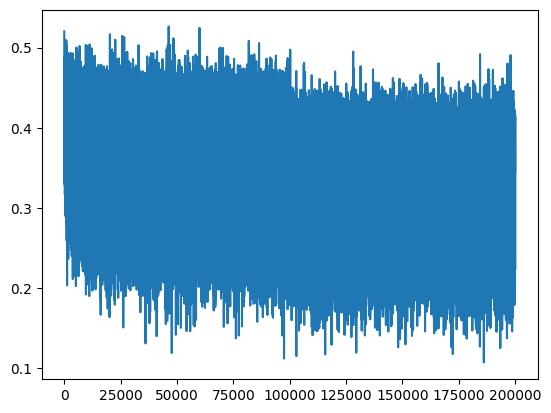

In [ ]:
# MLP
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),                generator = g)
W1 = torch.randn((n_embd * block_size, n_hidden),    generator = g)
b1 = torch.randn((n_hidden),                         generator = g)
W2 = torch.randn((n_hidden, vocab_size),             generator = g) * 0.01
b2 = torch.rand((vocab_size),                       generator = g) * 0
parameters = [C, W1, b1, W2, b2]

print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


# Optimization
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # gradient descent
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

plt.plot(lossi)


# Evaluate
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')


Look how the loss at the 0th step is now ≈3.3, not 27 anymore. The model was also improved a bit in comparison to a val loss of 2.13

Another thing to note. b1 is randomly initialized, and will be widely spread out. Looking at activation functions like tanh, extremely negative and positive values will have a gradient of 0 (or really close). This would effectively kill the neuron, as regardless of previous gradients, the local gradient of the activation would be extremely small/0, rendering it useless.

To fix, either scale b1 down or just make it 0, and scale down the weights as well.

11897
      0/ 200000: 3.3002
  10000/ 200000: 2.3795
  20000/ 200000: 2.4540
  30000/ 200000: 2.2504
  40000/ 200000: 2.1094
  50000/ 200000: 2.3294
  60000/ 200000: 2.6862
  70000/ 200000: 2.3647
  80000/ 200000: 2.3002
  90000/ 200000: 2.3127
 100000/ 200000: 2.1670
 110000/ 200000: 2.0801
 120000/ 200000: 2.0346
 130000/ 200000: 2.2609
 140000/ 200000: 2.2222
 150000/ 200000: 2.1762
 160000/ 200000: 2.0010
 170000/ 200000: 1.8729
 180000/ 200000: 2.2427
 190000/ 200000: 1.8950
train 2.034379005432129
val 2.1037144660949707


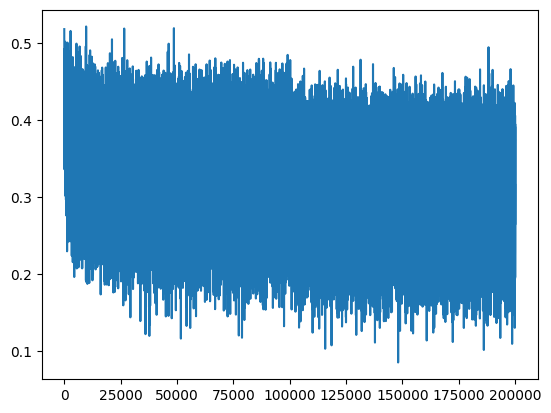

In [29]:
# MLP
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),                generator = g)
W1 = torch.randn((n_embd * block_size, n_hidden),    generator = g) * 0.2
b1 = torch.randn((n_hidden),                         generator = g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),             generator = g) * 0.01
b2 = torch.rand((vocab_size),                       generator = g) * 0
parameters = [C, W1, b1, W2, b2]

print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


# Optimization
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # gradient descent
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

plt.plot(lossi)


# Evaluate
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')


It is clear that fixing the initialization of the weights biases helped training, but how can we be sure by what to scale each of them by?

It turns out the weights have to be scaled by "gain / std", which in the case of tanh, gain is 5/3, and std in my case is sqrt(fan_in), which is sqrt(30). This should be applied to the weights of every hidden layer.

The ouput layer should be scaled down differently as it needs to be squashed even more in order to get a good probability spread.

tensor(0.0034) tensor(1.0066)
tensor(0.0007) tensor(1.0054)


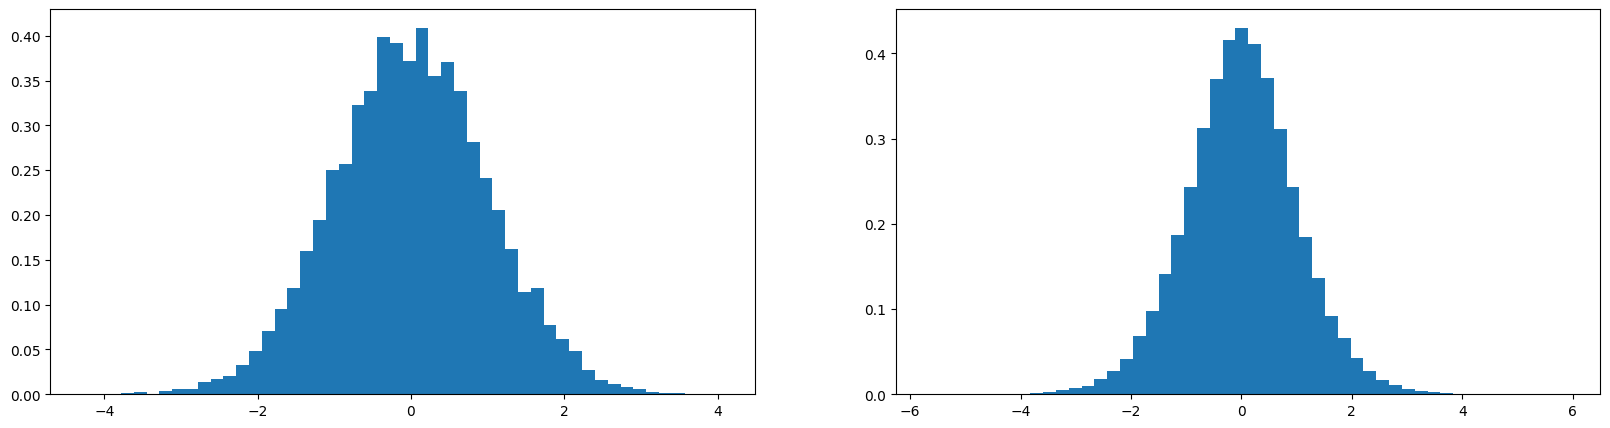

In [36]:
fan_in = 10
x = torch.randn(1000, 10)
w = torch.randn(fan_in, 200) / 10**0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);

11897
      0/ 200000: 3.3058
  10000/ 200000: 2.4037
  20000/ 200000: 2.4670
  30000/ 200000: 2.2157
  40000/ 200000: 2.1257
  50000/ 200000: 2.2898
  60000/ 200000: 2.6058
  70000/ 200000: 2.4257
  80000/ 200000: 2.3043
  90000/ 200000: 2.2971
 100000/ 200000: 2.0984
 110000/ 200000: 2.1124
 120000/ 200000: 2.0911
 130000/ 200000: 2.2468
 140000/ 200000: 2.1763
 150000/ 200000: 2.1289
 160000/ 200000: 1.9280
 170000/ 200000: 1.8439
 180000/ 200000: 2.2295
 190000/ 200000: 1.9695
train 2.037937879562378
val 2.103426933288574


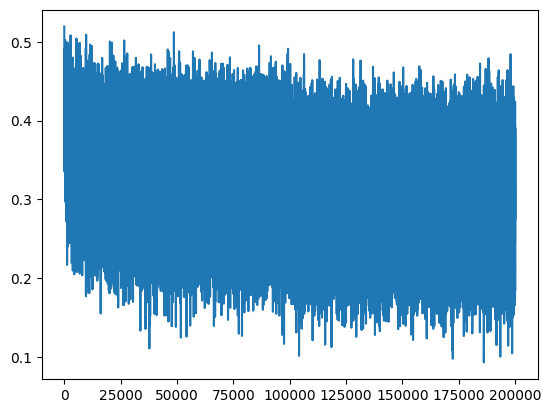

In [37]:
# MLP
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),                generator = g)
W1 = torch.randn((n_embd * block_size, n_hidden),    generator = g) * (5/3) / (n_embd * block_size)**0.5
b1 = torch.randn((n_hidden),                         generator = g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),             generator = g) * 0.01
b2 = torch.rand((vocab_size),                       generator = g) * 0
parameters = [C, W1, b1, W2, b2]

print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


# Optimization
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # gradient descent
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

plt.plot(lossi)


# Evaluate
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')


Ideally, we want hidden layer pre-activation values (hpreact) to be gaussian before the tanh activation. In the iteration below, hpreact is forced into gaussian

11897
      0/ 200000: 3.2959
  10000/ 200000: 2.3231
  20000/ 200000: 2.5278
  30000/ 200000: 2.1384
  40000/ 200000: 2.1825
  50000/ 200000: 2.4085
  60000/ 200000: 2.5511
  70000/ 200000: 2.4953
  80000/ 200000: 2.3154
  90000/ 200000: 2.4695
 100000/ 200000: 2.1484
 110000/ 200000: 2.1567
 120000/ 200000: 2.0829
 130000/ 200000: 2.4648
 140000/ 200000: 2.3158
 150000/ 200000: 2.1579
 160000/ 200000: 2.0005
 170000/ 200000: 1.9344
 180000/ 200000: 2.2822
 190000/ 200000: 1.9496
train 2.7509734630584717
val 2.8111886978149414


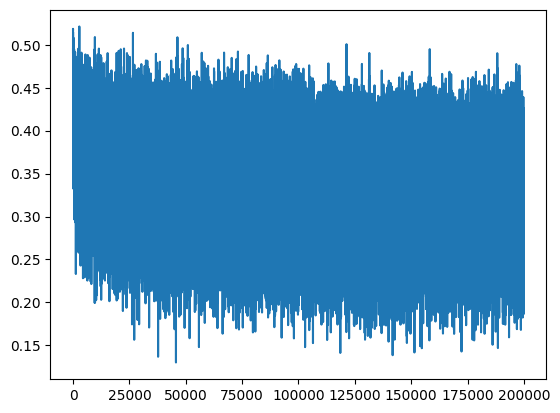

In [38]:
# MLP
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),                generator = g)
W1 = torch.randn((n_embd * block_size, n_hidden),    generator = g) * (5/3) / (n_embd * block_size)**0.5
b1 = torch.randn((n_hidden),                         generator = g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),             generator = g) * 0.01
b2 = torch.rand((vocab_size),                       generator = g) * 0
parameters = [C, W1, b1, W2, b2]

print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


# Optimization
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    hpreact = (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) # layer norm
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # gradient descent
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

plt.plot(lossi)


# Evaluate
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')


The model didn't perform very well this time. This is because in the optimization loop, hpreact is forced gaussian at every step. We only want that at initialization. After that, the network would want to shift it tweak hpreact as needed.

Another mechanism is needed: bn scale and shift. Scales and offsets the pre-activation values prior to tanh in each step of optimization.

We'll initalize bngain as a ones and bnbias as zeroes. At the first step of optimization, these values will cause hpreact to become perfectly gaussian. We want these tensors to also be modified via backpropagation and gradient descent, so will add them to the parameters array.

12297
      0/ 200000: 3.2959
  10000/ 200000: 2.3293
  20000/ 200000: 2.4701
  30000/ 200000: 2.1102
  40000/ 200000: 2.1149
  50000/ 200000: 2.3820
  60000/ 200000: 2.5595
  70000/ 200000: 2.5452
  80000/ 200000: 2.3360
  90000/ 200000: 2.4282
 100000/ 200000: 2.1227
 110000/ 200000: 2.1398
 120000/ 200000: 2.1000
 130000/ 200000: 2.4179
 140000/ 200000: 2.2418
 150000/ 200000: 2.1960
 160000/ 200000: 2.0614
 170000/ 200000: 1.9080
 180000/ 200000: 2.3157
 190000/ 200000: 1.8989
train 2.0662171840667725
val 2.1112899780273438


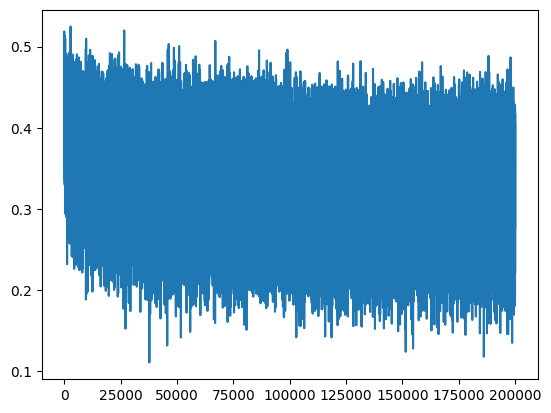

In [41]:
# MLP
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),                generator = g)
W1 = torch.randn((n_embd * block_size, n_hidden),    generator = g) * (5/3) / (n_embd * block_size)**0.5
b1 = torch.randn((n_hidden),                         generator = g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),             generator = g) * 0.01
b2 = torch.rand((vocab_size),                       generator = g) * 0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]


print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


# Optimization
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias # layer norm
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # gradient descent
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

plt.plot(lossi)


# Evaluate
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias # layer norm
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')


To sample, we pass in a letter and get predictions. However, with batchnorm, batches are expected. We must pass through the entire training set, and calculate the mean and std over the entire thing.

This constant mean and std are used in the hidden layer pre-activation value calculations, and are compatible with a single input instead of a batch.

In [42]:
# calibrate the batch norm at the end of training

with torch.no_grad():
    # pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    # measure the mean/std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

In [44]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1
    # hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias # layer norm
    hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias # layer norm
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0662171840667725
val 2.1112520694732666


Putting it all together:
- In initialization, we create a batch norm running mean and standard deviation. This will get tweaked throughout training for each batch
- For each batch, during the forward pass, the running BN mean and std are tweaked with respect to the mean and std for that specific batch. No gradient tracking is used to prevent it from affecting backprop (the mean and standrard deviation are not parameters, so must not affect backprop).
- After training, the calibration block calculates the mean and std over the entire training set, which can then be used in the evaluation function for sampling.

12297
      0/ 200000: 3.2959
  10000/ 200000: 2.3293
  20000/ 200000: 2.4701
  30000/ 200000: 2.1102
  40000/ 200000: 2.1149
  50000/ 200000: 2.3820
  60000/ 200000: 2.5595
  70000/ 200000: 2.5452
  80000/ 200000: 2.3360
  90000/ 200000: 2.4282
 100000/ 200000: 2.1227
 110000/ 200000: 2.1398
 120000/ 200000: 2.1000
 130000/ 200000: 2.4179
 140000/ 200000: 2.2418
 150000/ 200000: 2.1960
 160000/ 200000: 2.0614
 170000/ 200000: 1.9080
 180000/ 200000: 2.3157
 190000/ 200000: 1.8989
train 2.066169500350952
val 2.11173939704895


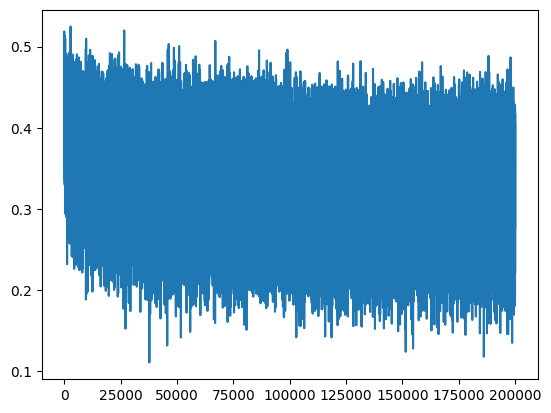

In [45]:
# MLP
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),                generator = g)
W1 = torch.randn((n_embd * block_size, n_hidden),    generator = g) * (5/3) / (n_embd * block_size)**0.5
b1 = torch.randn((n_hidden),                         generator = g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),             generator = g) * 0.01
b2 = torch.rand((vocab_size),                       generator = g) * 0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bn_mean_running = torch.zeros((1, n_hidden))
bn_std_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]


print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


# Optimization
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias # layer norm
    with torch.no_grad():
        bn_mean_running = 0.999 * bn_mean_running + 0.001 * bnmeani
        bn_std_running = 0.999 * bn_std_running + 0.001 * bnstdi
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # gradient descent
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

plt.plot(lossi)

# calibrate the batch norm at the end of training
with torch.no_grad():
    # pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    # measure the mean/std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

# Evaluate
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - bn_mean_running) / bn_std_running + bnbias # layer norm
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')


In fact, the calibration block isnt even needed, because we tweak the running mean and std inline for each batch during it's forward pass.

12297
      0/ 200000: 3.2959
  10000/ 200000: 2.3293
  20000/ 200000: 2.4701
  30000/ 200000: 2.1102
  40000/ 200000: 2.1149
  50000/ 200000: 2.3820
  60000/ 200000: 2.5595
  70000/ 200000: 2.5452
  80000/ 200000: 2.3360
  90000/ 200000: 2.4282
 100000/ 200000: 2.1227
 110000/ 200000: 2.1398
 120000/ 200000: 2.1000
 130000/ 200000: 2.4179
 140000/ 200000: 2.2418
 150000/ 200000: 2.1960
 160000/ 200000: 2.0614
 170000/ 200000: 1.9080
 180000/ 200000: 2.3157
 190000/ 200000: 1.8989
train 2.066169500350952
val 2.11173939704895


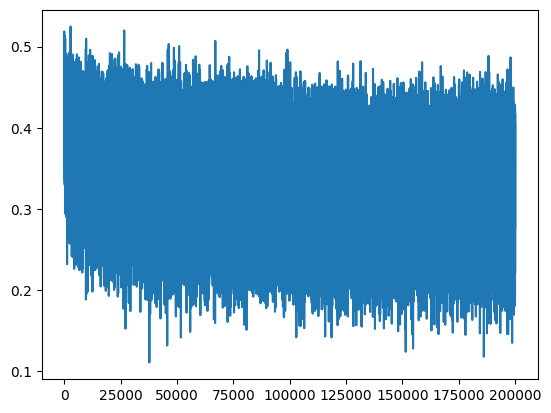

In [46]:
# MLP
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),                generator = g)
W1 = torch.randn((n_embd * block_size, n_hidden),    generator = g) * (5/3) / (n_embd * block_size)**0.5
b1 = torch.randn((n_hidden),                         generator = g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),             generator = g) * 0.01
b2 = torch.rand((vocab_size),                       generator = g) * 0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bn_mean_running = torch.zeros((1, n_hidden))
bn_std_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]


print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


# Optimization
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias # layer norm
    with torch.no_grad():
        bn_mean_running = 0.999 * bn_mean_running + 0.001 * bnmeani
        bn_std_running = 0.999 * bn_std_running + 0.001 * bnstdi
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # gradient descent
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

plt.plot(lossi)

# Evaluate
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - bn_mean_running) / bn_std_running + bnbias # layer norm
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')
 

Another note:
- b1 is redundant, as it gets subtracted out of hpreact in batch norm
- It can be removed (for any layer before batch norm) 

12097
      0/ 200000: 3.3013
  10000/ 200000: 2.1925
  20000/ 200000: 2.2441
  30000/ 200000: 2.1717
  40000/ 200000: 2.0189
  50000/ 200000: 1.8611
  60000/ 200000: 2.3872
  70000/ 200000: 2.0463
  80000/ 200000: 2.3295
  90000/ 200000: 2.0302
 100000/ 200000: 2.0447
 110000/ 200000: 2.0821
 120000/ 200000: 2.6024
 130000/ 200000: 1.8348
 140000/ 200000: 1.9346
 150000/ 200000: 2.1799
 160000/ 200000: 1.9426
 170000/ 200000: 1.7346
 180000/ 200000: 2.1020
 190000/ 200000: 2.3562
train 2.065276622772217
val 2.1086678504943848


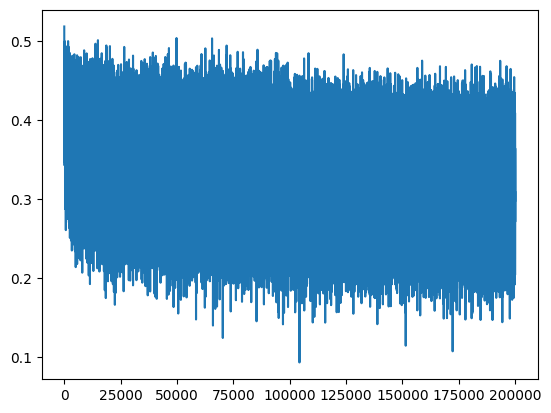

In [47]:
# MLP
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),                generator = g)
W1 = torch.randn((n_embd * block_size, n_hidden),    generator = g) * (5/3) / (n_embd * block_size)**0.5
# b1 = torch.randn((n_hidden),                         generator = g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),             generator = g) * 0.01
b2 = torch.rand((vocab_size),                       generator = g) * 0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bn_mean_running = torch.zeros((1, n_hidden))
bn_std_running = torch.ones((1, n_hidden))

# parameters = [C, W1, b1, W2, b2, bngain, bnbias]
parameters = [C, W1, W2, b2, bngain, bnbias]


print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


# Optimization
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    # Linear layer
    hpreact = embcat @ W1 #+ b1
    # BatchNorm layer
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias # batch norm
    with torch.no_grad():
        bn_mean_running = 0.999 * bn_mean_running + 0.001 * bnmeani
        bn_std_running = 0.999 * bn_std_running + 0.001 * bnstdi
    # Non-linearity
    h = torch.tanh(hpreact)
    # Output layer
    logits = h @ W2 + b2
    # Loss
    loss = F.cross_entropy(logits, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # gradient descent
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

plt.plot(lossi)

# Evaluate
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 #+ b1
    hpreact = bngain * (hpreact - bn_mean_running) / bn_std_running + bnbias # layer norm
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')
 

Before moving on, lets clean the code up.
- Cell below sets up the modules and neural network.
- Next cell afterwards is the training loop

Note the following interation is flawed (uses a gain of 5/3 when 1 would be better). There is no batchnorm on purpose but just walk through it anyways.

In [62]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # Parameters from backprop
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # Buffers: running values
        self.running_mean = torch.zeros(dim)
        self.running_std = torch.ones(dim)
    
    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)  # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
        
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []


# Build the network using the modules from above
n_embd = 10
n_hidden = 100 # the number of neurons in the hidden layer
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd),           generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden), Tanh(),
    Linear(         n_hidden, n_hidden), Tanh(),
    Linear(         n_hidden, n_hidden), Tanh(),
    Linear(         n_hidden, n_hidden), Tanh(),
    Linear(         n_hidden, n_hidden), Tanh(),
    Linear(         n_hidden, vocab_size),
]

with torch.no_grad():
    # last layer: make less confident
    layers[-1].weight *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

46497


In [64]:
# Training loop
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # forward pass
    emb = C[Xb] # embed the characters into vectors
    x = emb.view(emb.shape[0], -1) # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)
    
    # backward pass
    for layer in layers:
        layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])
    
    if i >= 1000:
        break # Run 1 step first

      0/ 200000: 3.3245


The image below plots activation values on the x and occurences on the y.
- Layer 1 has the most the most saturated neurons, showing high occurences of -1s, and 1s (dead neurons basically). As we progress to the next layers, there is less of/no spike at -1 and 1, indicating that the neurons are active.
- This is due to the gain that we initialized at 5/3. This is the give value for tanh, but each activation function has their own.
- A gain too low (1) standard deviation would approach 1.
- A gain too high would increase the saturation of each layer.

layer 1 (      Tanh): mean -0.06, std 0.76, saturated: 21.53%
layer 3 (      Tanh): mean +0.01, std 0.72, saturated: 11.72%
layer 5 (      Tanh): mean -0.02, std 0.73, saturated: 13.75%
layer 7 (      Tanh): mean -0.02, std 0.73, saturated: 14.25%
layer 9 (      Tanh): mean -0.01, std 0.70, saturated: 10.31%


Text(0.5, 1.0, 'activation distribution')

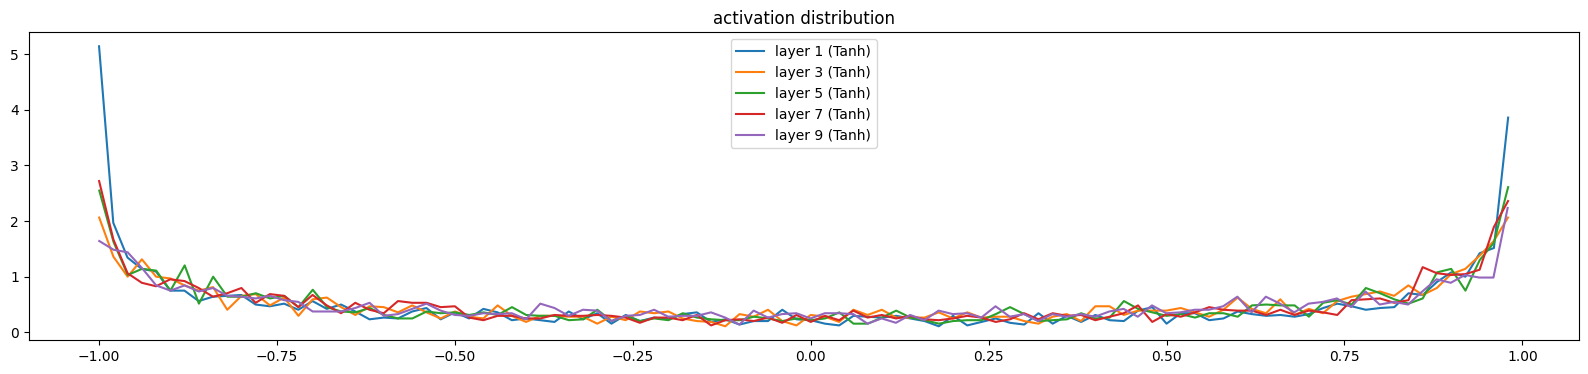

In [65]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('activation distribution')

Below shows a graph of the gradients of each tanh layer's outputs.

layer 1 (      Tanh): mean -0.000048, std 3.441711e-03
layer 3 (      Tanh): mean -0.000058, std 3.294971e-03
layer 5 (      Tanh): mean +0.000016, std 3.042349e-03
layer 7 (      Tanh): mean -0.000035, std 2.901085e-03
layer 9 (      Tanh): mean +0.000016, std 2.376518e-03


Text(0.5, 1.0, 'gradient distribution')

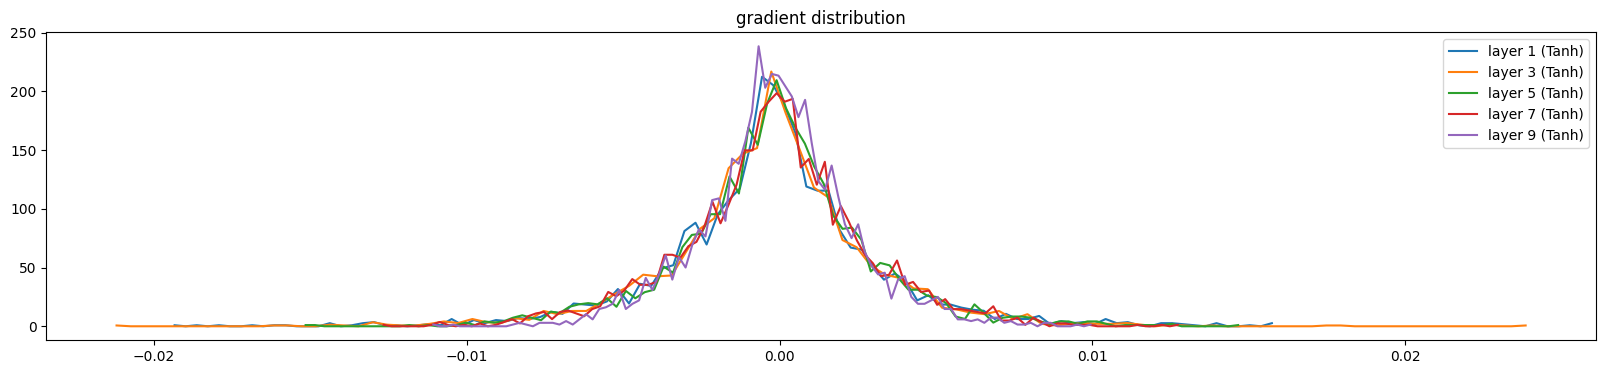

In [66]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('gradient distribution')


weight   (27, 10) | mean -0.000778 | std 1.119964e-02 | grad:data ratio 1.119103e-02
weight  (30, 100) | mean -0.000006 | std 9.959947e-03 | grad:data ratio 3.182399e-02
weight (100, 100) | mean +0.000035 | std 8.234480e-03 | grad:data ratio 4.900468e-02
weight (100, 100) | mean +0.000091 | std 7.020393e-03 | grad:data ratio 4.141926e-02
weight (100, 100) | mean -0.000049 | std 6.007066e-03 | grad:data ratio 3.559794e-02
weight (100, 100) | mean -0.000000 | std 4.967416e-03 | grad:data ratio 2.949064e-02
weight  (100, 27) | mean +0.000000 | std 2.013820e-02 | grad:data ratio 2.855440e-01


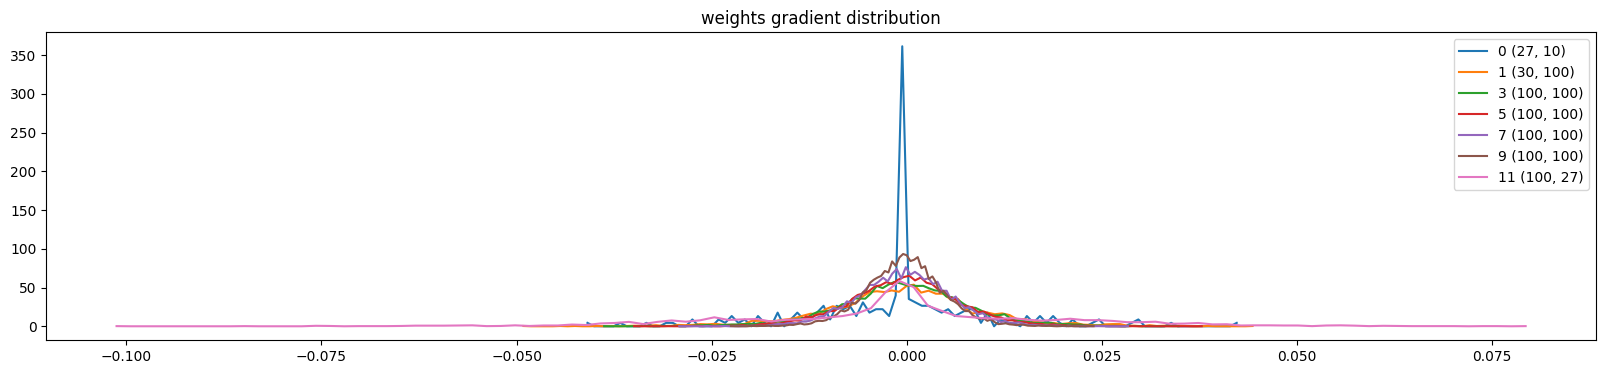

In [67]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std()/p.data.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

The graph below plots gradient-to-data ratio over training. The target ratio is 1e-3, which would indicate an appropriate learning rate.

- We want to ideally have every parameter at 3 (1e-3) or a bit higher.
- Lower is worse, as it indicated the model is learning too slowly.

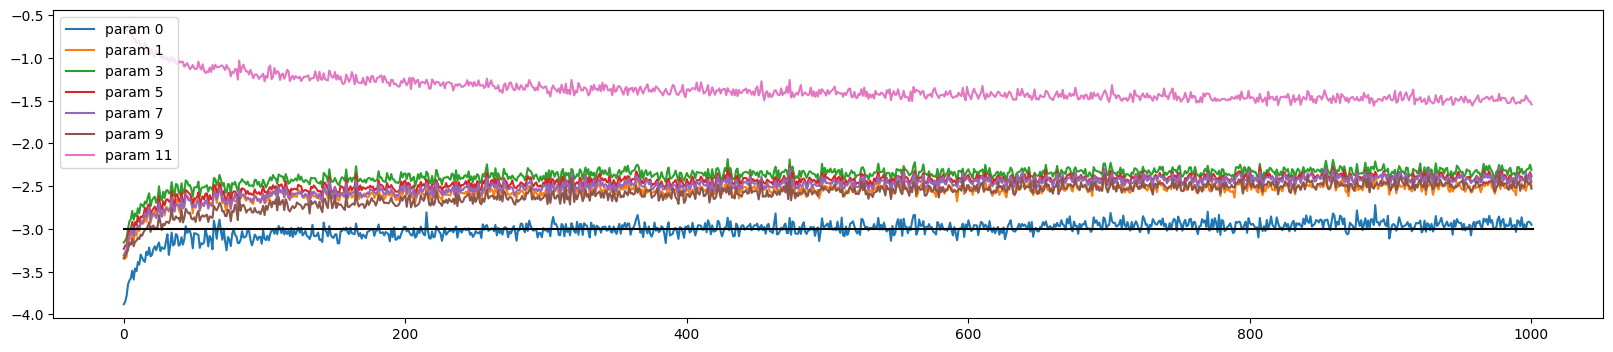

In [68]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

The entire neural network iteration above is weird, since there is no batchnorm, and as a result the neurons behaved weirdly. Ideally, we want the neuron activations and gradients to both be a bell shape (gaussian).

- tanh(0) is the most active a neuron can be. tanh(-1) and tanh(1) = 0 (the neuron would be inactive).
- A bell curve would indicate that majority of neurons have a preactivation value of 0 give or take, resulting in more activity and better learning in the network.

Below is the incorporation of batchnorm:
- Put a batchnorm layer after each linear layer, but before the nonlinearity (tanh activation).
- Initially, I had a confidence multiplier to scale down the weight to lower the confidence of the output layer. Now, since the final output is from the batchnorm layer, I changed this to the gamma instead of a weight. This is because the gamma is what is multiplying the normalized activations.

In [73]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # Parameters from backprop
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # Buffers: running values
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)  # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
        
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []


# Build the network using the modules from above
n_embd = 10
n_hidden = 100 # the number of neurons in the hidden layer
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd),           generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(         n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(         n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(         n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(         n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(         n_hidden, vocab_size), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    # last layer: make less confident
    # Changing the gamma instead of the weight, as gamma is what mutliplies with the normalized output (not the 'weight' anymore)
    layers[-1].gamma *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

47551


In [74]:
# Training loop
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # forward pass
    emb = C[Xb] # embed the characters into vectors
    x = emb.view(emb.shape[0], -1) # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)
    
    # backward pass
    for layer in layers:
        layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])
    
    if i >= 1000:
        break # Run 1 step first

      0/ 200000: 3.3313


layer 2 (      Tanh): mean -0.00, std 0.64, saturated: 2.56%
layer 5 (      Tanh): mean -0.01, std 0.64, saturated: 2.59%
layer 8 (      Tanh): mean -0.01, std 0.64, saturated: 2.31%
layer 11 (      Tanh): mean -0.01, std 0.64, saturated: 2.81%
layer 14 (      Tanh): mean -0.00, std 0.64, saturated: 2.34%
layer 2 (      Tanh): mean +0.000000, std 3.860918e-03
layer 5 (      Tanh): mean +0.000000, std 3.310031e-03
layer 8 (      Tanh): mean +0.000000, std 3.105930e-03
layer 11 (      Tanh): mean +0.000000, std 2.750409e-03
layer 14 (      Tanh): mean -0.000000, std 2.485619e-03
weight   (27, 10) | mean +0.000000 | std 9.878527e-03 | grad:data ratio 9.868573e-03
weight  (30, 100) | mean -0.000094 | std 8.747967e-03 | grad:data ratio 2.799229e-02
weight (100, 100) | mean +0.000160 | std 7.655443e-03 | grad:data ratio 4.581044e-02
weight (100, 100) | mean +0.000066 | std 6.817395e-03 | grad:data ratio 4.043709e-02
weight (100, 100) | mean +0.000010 | std 6.177770e-03 | grad:data ratio 3.68

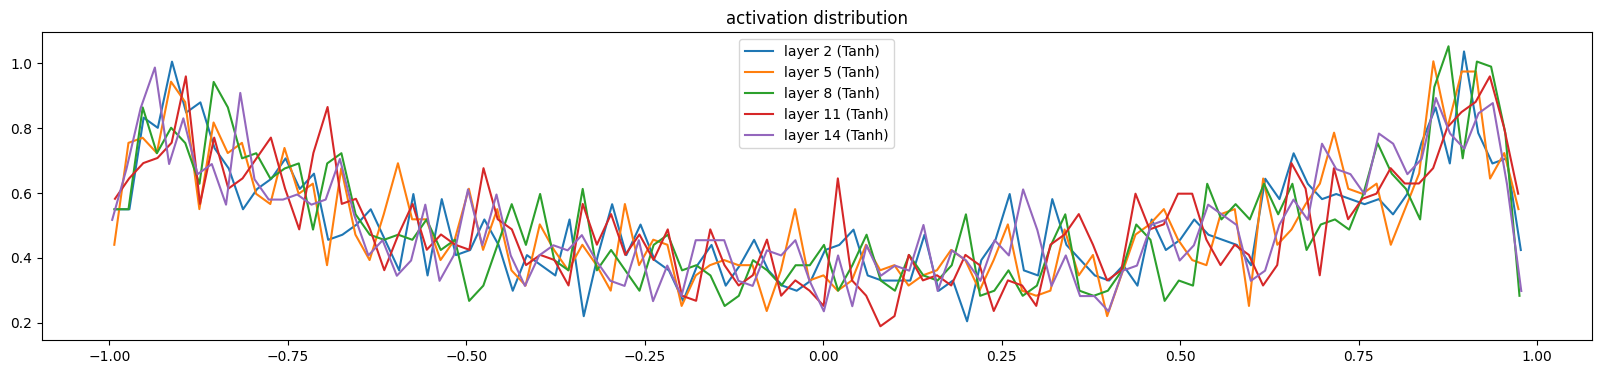

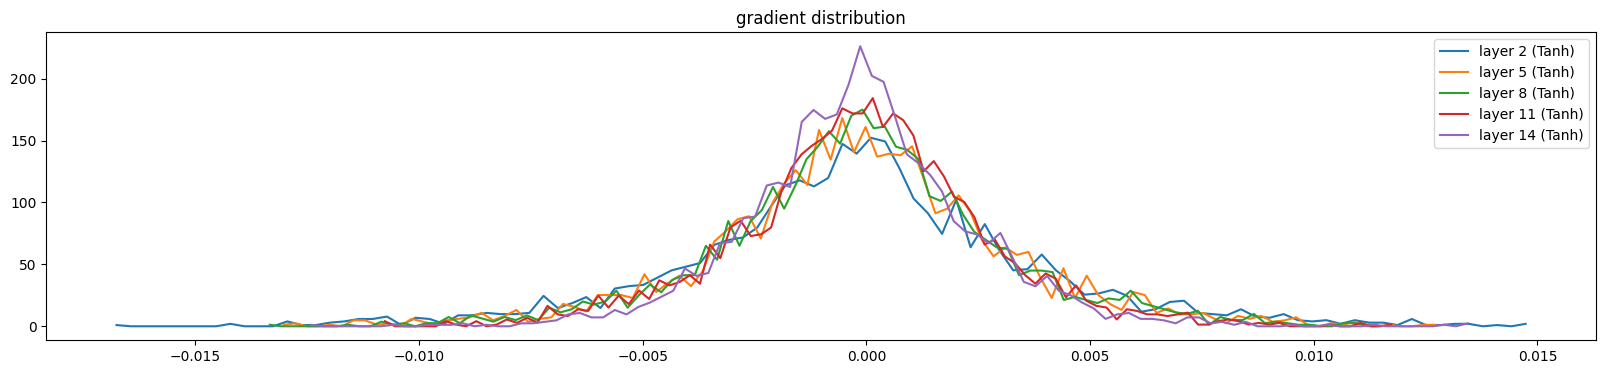

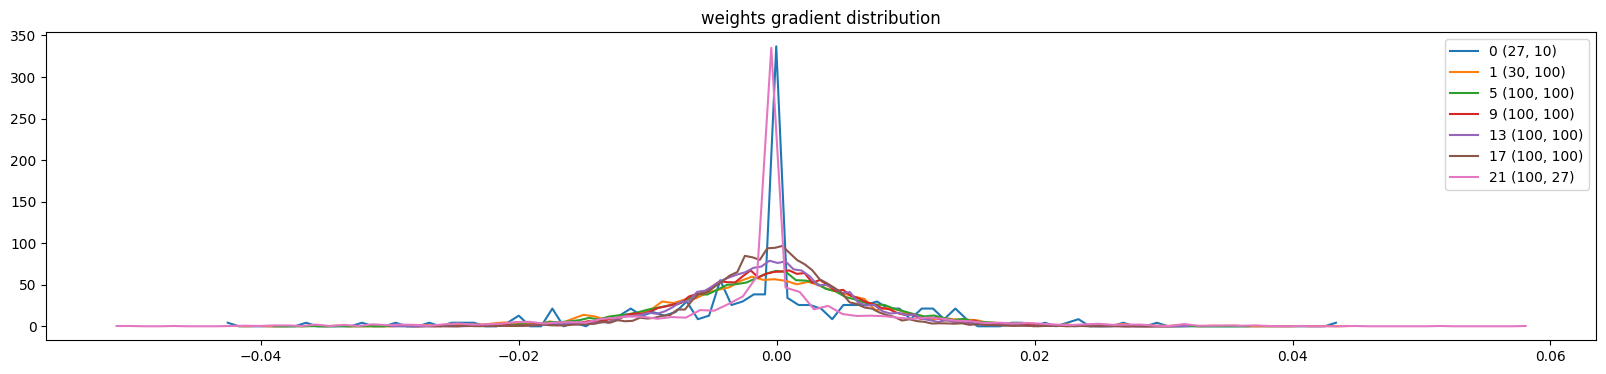

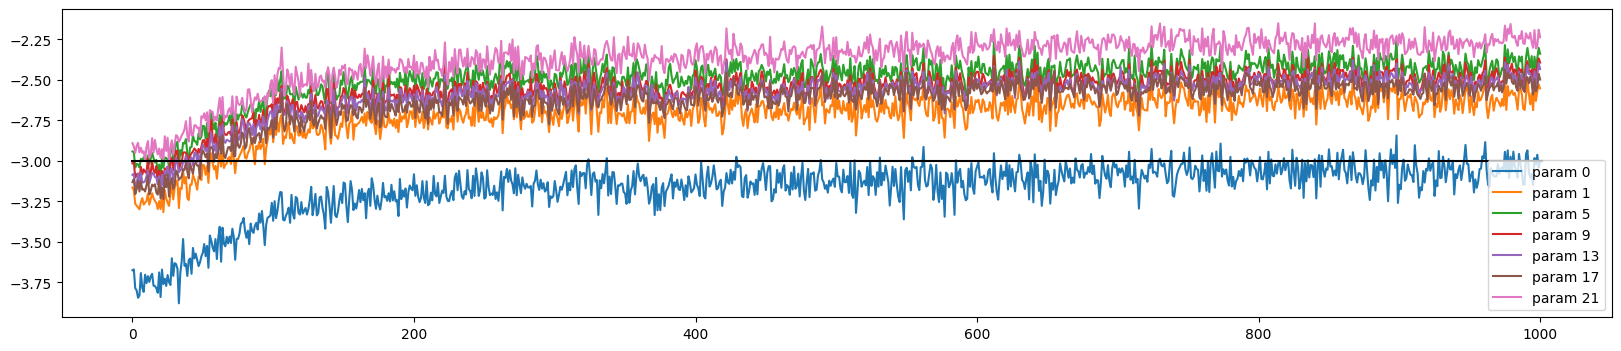

In [75]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('activation distribution')


# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('gradient distribution')


# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std()/p.data.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');


plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);
